# Análisis Exploratorio de Datos
El objetivo de este notebook es explorar el conjunto de datos `selectedDataset.csv`, el cual ha sido previamente limpiado para conservar únicamente las variables relevantes para el estudio. A través de este análisis, se busca visualizar y comprender el comportamiento de la información. La metodología adoptada se fundamenta en el documento 'A Practical Guide to Introduce Exploratory Data Analysis with Python' [1]. Como ilustra el esquema a continuación, el análisis seguirá una estructura lógica secuencial: iniciaremos con la importación de las librerías necesarias, seguido de un análisis descriptivo para obtener una visión representativa de los datos y la validación de los tipos de variables para asegurar su consistencia. Posteriormente, se abordará el tratamiento de valores faltantes y atípicos (outliers) con el fin de evitar sesgos en los resultados estadísticos. Finalmente, examinaremos las relaciones numéricas y visuales entre las variables.

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import haversine as hs
from haversine import Unit
import seaborn as sns

Se agrega la dataset limpia y se nombra `df`. Con esto estaremos trabajando.

In [26]:
df = pd.read_csv('../data/selectedDataset.csv')

### Análisis Descriptivo

Como paso inicial, se realizará una inspección de la estructura del dataset para identificar las variables disponibles y definir sus respectivos tipos de datos, los cuales se detallan a continuación:

- **Order_ID** (`int`): Identificador único de cada pedido.
- **Restaurant_ID** (`int`): Identificador único del local despachador.
- **City** (`string`): Ciudad donde ocurre la entrega.
- **Restaurant_Lat** (`float`): Latitud geográfica del restaurante.
- **Restaurant_Lon** (`float`): Longitud geográfica del restaurante.
- **Customer_Lat** (`float`): Latitud geográfica del cliente.
- **Customer_Lon** (`float`): Longitud geográfica del cliente.
- **Order_Time** (`datetime`): Fecha y hora exacta de la compra.
- **Delivery_Time** (`datetime`): Fecha y hora de llegada al cliente.
- **Delivery_Duration_Minutes** (`int`): Tiempo total del viaje en minutos.

In [27]:
# De esta forma, para ver las primeras 5 columnas utilizados head
df.head()

,Order_ID,Restaurant_ID,City,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Order_Time,Delivery_Time,Delivery_Duration_Minutes
0,1,358,Alexandria,31.195082,29.921931,31.191404,29.904982,2025-06-16 08:32:00,2025-06-16 09:11:00,39
1,2,316,Zagazig,30.605729,31.503079,30.586047,31.485820,2025-06-03 21:27:00,2025-06-03 22:00:00,33
2,3,357,Assiut,27.190180,31.177741,27.164869,31.169218,2025-06-01 14:48:00,2025-06-01 15:26:00,38
3,4,420,Mansoura,31.041846,31.381229,31.035773,31.380440,2025-06-13 02:30:00,2025-06-13 03:22:00,52
4,5,73,Mansoura,31.024141,31.376104,31.026023,31.396881,2025-06-06 09:48:00,2025-06-06 10:32:00,44


In [28]:
# Con esto vemos los tipos
df.dtypes

Order_ID                       int64
Restaurant_ID                  int64
City                             str
Restaurant_Lat               float64
Restaurant_Lon               float64
Customer_Lat                 float64
Customer_Lon                 float64
Order_Time                       str
Delivery_Time                    str
Delivery_Duration_Minutes      int64
dtype: object

### Ajuste de Tipos de Variable

Para asegurar la consistencia del conjunto de datos, se ajustaron los tipos de variables según su naturaleza. Específicamente, las variables correspondientes a registros horarios se transformaron de `string` a `datetime`. A partir de estas variables, se extraerán atributos temporales específicos para generar nuevas columnas que enriquecerán el análisis.

In [29]:
df['Order_Time'] = pd.to_datetime(df['Order_Time'])
df['Delivery_Time'] = pd.to_datetime(df['Delivery_Time'])

df['Order_Hour'] = df['Order_Time'].dt.hour
df['Order_Date'] = df['Order_Time'].dt.date
df['Delivery_Hour'] = df['Delivery_Time'].dt.hour
df['Week_Day'] = df['Order_Time'].dt.day_name()

### Detección y Tratamiento de Missing Data

Luego, procederemos a revisar la presencia de datos nulos. A pesar de la limpieza inicial, esta comprobación es necesaria para asegurar la calidad de la información. Tal como se evidencia, el dataset se encuentra completamente libre de datos nulos, por lo que no se debe realizar ningún tratamiento.

In [30]:
df.isnull().sum()

Order_ID                     0
Restaurant_ID                0
City                         0
Restaurant_Lat               0
Restaurant_Lon               0
Customer_Lat                 0
Customer_Lon                 0
Order_Time                   0
Delivery_Time                0
Delivery_Duration_Minutes    0
Order_Hour                   0
Order_Date                   0
Delivery_Hour                0
Week_Day                     0
dtype: int64

### Estudio de Variables

En este caso, un describe para los datos es netamente innecesario, ya que no tiene mucho sentido por los datos que tenemos. Eso sí, es importante revisar temas como la fecha inicial y la fecha final del estudio. Asímismo, el largo de latitudes y longitudes que existen. Tambien ver la cantidad de restaurantes y la cantidad de ciudades.

In [41]:
print(f"Lapso de datos: {df['Order_Date'].min()} a {df['Order_Date'].max()}")
print(f"Rango de latitudes para restaurantes): {df['Restaurant_Lat'].min()} a {df['Restaurant_Lat'].max()}")
print(f"Rango de longitudes para restaurantes: {df['Restaurant_Lon'].min()} a {df['Restaurant_Lon'].max()}")
print(f"Cantidad de Restaurantes: {df['Restaurant_ID'].nunique()}")
print(f"Cantidad de Ciudades: {df['City'].nunique()}")

Lapso de datos: 2025-06-01 a 2025-06-16
Rango de latitudes para restaurantes): 27.160900337288453 a 31.22009888589472
Rango de longitudes para restaurantes: 29.8987010496784 a 31.521996852107776
Cantidad de Restaurantes: 1000
Cantidad de Ciudades: 7


Entonces para continuar, analizamos la cantidad de pedidos por ciudad, identificando a **Zagazig** como el lugar con mayor demanda de pedidos. También, se calculan las estadísticas descriptivas de los tiempos de viaje para cada ubicación, que evidencian resultados como que el tiempo promedio de entrega se sitúa de manera uniforme alrededor de los **37.5 minuto**s en todas las ciudades, con tiempos extremos idénticos que oscilan entre un mínimo de **15** y un máximo de **60 minutos**.

In [ ]:
# Estadísticas por ciudad
df.groupby('City')['Delivery_Duration_Minutes'].agg([('count', 'count'), ('mean', 'mean'), ('median', 'median'), ('std', 'std'), ('min', 'min'), ('max', 'max')]).round(3)

,count,mean,median,std,min,max
City,,,,,,
Alexandria,14167,37.454,38.0,10.081,15,60
Assiut,14302,37.625,38.0,10.054,15,60
Cairo,14381,37.448,37.0,10.030,15,60
Giza,14232,37.399,37.0,10.059,15,60
Mansoura,14044,37.573,38.0,10.079,15,60
Tanta,14336,37.473,37.0,10.108,15,60
Zagazig,14538,37.666,38.0,10.016,15,60


Además, al analizar la cantidad de restaurantes únicos por ciudad, se observa una distribución perfectamente equilibrada, registrando exactamente **1000 establecimientos** en cada una de las ubicaciones

In [53]:
df.groupby('City')['Restaurant_ID'].nunique()

City
Alexandria    1000
Assiut        1000
Cairo         1000
Giza          1000
Mansoura      1000
Tanta         1000
Zagazig       1000
Name: Restaurant_ID, dtype: int64

Otro punto importante a considerar son las distancias. Para calcular esto, dado que en este momento solamente se tienen valores de longitud y latitud, se utilizará la **Fórmula de Haversine** [2], que permite medir la distancia real en línea recta entre dos puntos del mapa considerando la curvatura de la Tierra. En el código, se agrupa la latitud y longitud, y se hace uso de la librería `haversine` para obtener los kilómetros.

In [77]:
def haversine_distance(lat1, lon1, lat2, lon2):
    origen = (lat1, lon1)
    destino = (lat2, lon2)
    distancia_km = hs.haversine(origen, destino, unit=Unit.KILOMETERS)
    return distancia_km

Una vez definida la función, se aplica a todos los pedidos para crear una nueva columna de distancias (`Distance_km`). Luego, se extraen las estadísticas para entender qué tan lejos viajan los repartidores, donde se observa que el viaje promedio es de aproximadamente **2.16 km**. El recorrido más corto es de **0.008 km** y el más largo llega a los **5.6 km**. Esto define que se trabaja con repartos relativamente cortos dentro de la misma ciudad.

In [ ]:
df['Distance_km'] = df.apply(
    lambda row: haversine_distance(
        row['Restaurant_Lat'], row['Restaurant_Lon'],
        row['Customer_Lat'], row['Customer_Lon']
    ), axis=1
)

print(df['Distance_km'].describe())

count    100000.000000
mean          2.167108
std           1.039829
min           0.008829
25%           1.356672
50%           2.124226
75%           2.927053
max           5.603405
Name: Distance_km, dtype: float64


También agrupamos las distancias por ciudad para ver si existen diferencias importantes entre ellas. Ahora bien, los números son muy similares en todas las zonas, pues la distancia promedio siempre se mantiene cerca de los **2.16 km**, y los máximos no superan los **5.6 km**.

In [69]:
# Distancia por ciudad
df.groupby('City')['Distance_km'].agg([
    ('count', 'count'),
    ('mean', 'mean'),
    ('median', 'median'),
    ('std', 'std'),
    ('min', 'min'),
    ('max', 'max')
]).round(3)

,count,mean,median,std,min,max
City,,,,,,
Alexandria,14167,2.156,2.109,1.031,0.017,5.482
Assiut,14302,2.188,2.142,1.052,0.013,5.385
Cairo,14381,2.162,2.123,1.045,0.040,5.447
Giza,14232,2.164,2.120,1.032,0.011,5.315
Mansoura,14044,2.162,2.129,1.034,0.018,5.403
Tanta,14336,2.164,2.126,1.043,0.009,5.399
Zagazig,14538,2.172,2.124,1.041,0.016,5.603


### Análisis de Correlación
Ya finalizando, se realiza un cálculo de correlación para ver si existe una relación entre la distancia del viaje (`Distance_km`) y el tiempo que tardó el repartidor (`Delivery_Duration_Minutes`). Así, el gráfico muestra un valor de **-0.0017**, lo que significa que prácticamente no hay correlación. Es decir, recorrer más kilómetros no significó necesariamente demorar más tiempo, lo cual de cierta forma, tiene sentido, ya que el tiempo de entrega se podría ver afectado por el tráfico o la preparación en el local.

In [ ]:
correlation = df['Distance_km'].corr(df['Delivery_Duration_Minutes'])
print(f"Correlación entre distancia y duración: {correlation:.4f}")

Correlación entre distancia y duración: -0.0017


Para finalizar, se presenta un mapa de calor (*heatmap*) con el objetivo de evaluar la correlación entre las variables. Tal como se observó en el análisis previo, se confirma que no existe una correlación estadística entre la distancia y el tiempo de entrega. Por otro lado, existe una correlación positiva muy alta entre la hora del pedido y la hora de entrega, lo cual representa una progresión lógica natural (siendo una la consecuencia del otro). Finalmente, se evidencia que la hora del día no determina la distancia del viaje y tiene un impacto mínimo en lo que tarda el repartidor, lo que sugiere que probablemente no existe diferencia por horarios *peak*.

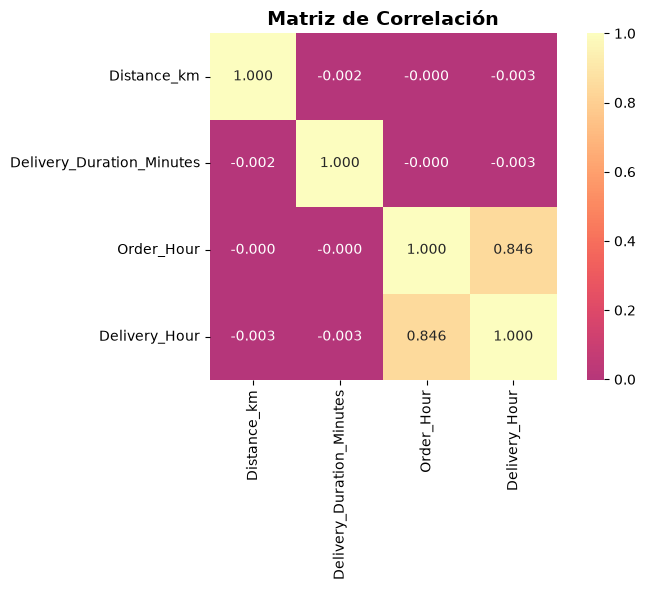

In [80]:
numColumns = ['Distance_km', 'Delivery_Duration_Minutes', 'Order_Hour', 'Delivery_Hour']
corr_matrix = df[numColumns].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='magma', center=0,
            square=True)

plt.title('Matriz de Correlación', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Bibliografía
Acá incluyo los links que utilicé para ciertos conceptos o valoraciones importantes.
* [1] Iniciativa Aporta, *"A Practical Guide to Introduce Exploratory Data Analysis with Python"*, datos.gob.es, 2021. https://datos.gob.es/sites/default/files/documentacion/files/guide_eda_python.pdf.
* [2] A. Bhardwaj, *"Calculating distance between two geo-locations in Python"*, Medium, jun. 2020. https://medium.com/data-science/calculating-distance-between-two-geolocations-in-python-26ad3afe287b.
